# 06. 피처 엔지니어링 — Lag / Rolling / Domain

> **목표**: 시계열 패턴 + 도메인 복합 피처로 MAE 향상  
> `src/feature_engineering.py` 모듈 사용 (ID 순서 버그 수정 버전)
>
> **⚠️ 버그 수정**: Lag/Rolling FE 후 test ID 순서 뒤바뀜 → `_orig_order` 기반 복원으로 수정

## 실험 순서
1. Base(ts) → Lag(1-3) → Lag+Roll → Full FE(+Domain)


## 1. 라이브러리 및 공통 함수

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
import sys; sys.path.insert(0, '../src')
from feature_engineering import (merge_layout, encode_categoricals, add_ts_features,
                                  add_lag_features, add_rolling_features,
                                  add_domain_features, get_feature_cols)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/'
TARGET = 'avg_delay_minutes_next_30m'
SEED = 42
N_SPLITS = 5
RESULTS = {}

lgb_params = {
    'objective': 'regression_l1', 'metric': 'mae',
    'num_leaves': 63, 'learning_rate': 0.05,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
    'min_child_samples': 20, 'n_estimators': 1000,
    'early_stopping_rounds': 100, 'verbose': -1, 'random_state': SEED,
}

def run_cv(train_df, test_df, label=''):
    feat_cols = get_feature_cols(train_df, TARGET)
    X = train_df[feat_cols].values
    y = train_df[TARGET].values
    groups = train_df['scenario_id'].values
    X_test = test_df[feat_cols].values

    gkf = GroupKFold(n_splits=N_SPLITS)
    oof = np.zeros(len(train_df))
    test_preds = []
    fold_maes = []
    last_model = None

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X[tr_idx], y[tr_idx], eval_set=[(X[val_idx], y[val_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X[val_idx]).clip(min=0)
        test_preds.append(model.predict(X_test).clip(min=0))
        mae = mean_absolute_error(y[val_idx], oof[val_idx])
        fold_maes.append(mae)
        last_model = model
        print(f'  [{label}] Fold {fold+1}: MAE={mae:.4f}, iter={model.best_iteration_}, feats={len(feat_cols)}')

    oof_mae = mean_absolute_error(y, oof)
    print(f'  [{label}] OOF MAE = {oof_mae:.4f} (std={np.std(fold_maes):.4f})')
    RESULTS[label] = {'mae': oof_mae, 'std': np.std(fold_maes), 'n_feats': len(feat_cols)}
    return oof_mae, np.std(fold_maes), oof, np.mean(test_preds, axis=0), feat_cols, last_model

print('설정 완료')


설정 완료


## 2. 데이터 로드

In [2]:
train_raw = pd.read_csv(DATA_PATH + 'train.csv')
test_raw  = pd.read_csv(DATA_PATH + 'test.csv')
layout    = pd.read_csv(DATA_PATH + 'layout_info.csv')

# ID 순서 저장 (검증용)
test_orig_ids = test_raw['ID'].values.copy()

print(f'Train: {train_raw.shape}, Test: {test_raw.shape}')
print(f'원본 test 첫 ID: {test_orig_ids[0]}, 마지막: {test_orig_ids[-1]}')


Train: (250000, 94), Test: (50000, 93)
원본 test 첫 ID: TEST_000000, 마지막: TEST_049999


## 3. 단계별 FE 및 CV 실험

In [3]:
# ── Step 0: Base 전처리 (layout + encoding + ts)
train_b, test_b = merge_layout(train_raw.copy(), test_raw.copy(), layout)
train_b, test_b = encode_categoricals(train_b, test_b, TARGET)
train_b = add_ts_features(train_b)
test_b  = add_ts_features(test_b)

print('=== Base (layout+ts, 버그 없음) ===')
mae_base, std_base, oof_base, test_base_pred, feat_base, _ = run_cv(train_b, test_b, 'Base(ts)')
assert (test_b['ID'].values == test_orig_ids).all(), '❌ ID 순서 오류!'
print('✅ ID 순서 확인 통과')


=== Base (layout+ts, 버그 없음) ===


  [Base(ts)] Fold 1: MAE=9.1028, iter=318, feats=108


  [Base(ts)] Fold 2: MAE=9.2708, iter=154, feats=108


  [Base(ts)] Fold 3: MAE=8.8043, iter=97, feats=108


  [Base(ts)] Fold 4: MAE=9.5541, iter=530, feats=108


  [Base(ts)] Fold 5: MAE=9.1628, iter=88, feats=108
  [Base(ts)] OOF MAE = 9.1790 (std=0.2431)
✅ ID 순서 확인 통과


In [4]:
# ── Step 1: Lag 피처 추가
train_lag, test_lag = add_lag_features(train_b, test_b)
assert (test_lag['ID'].values == test_orig_ids).all(), '❌ Lag 후 ID 순서 오류!'
print('✅ Lag 후 ID 순서 확인 통과')

print('=== Lag 피처 추가 ===')
mae_lag, std_lag, oof_lag, test_lag_pred, feat_lag, _ = run_cv(train_lag, test_lag, 'Lag(1-3)')
print(f'개선: {mae_base - mae_lag:+.4f}분 ({(mae_base-mae_lag)/mae_base*100:+.2f}%)')


✅ Lag 후 ID 순서 확인 통과
=== Lag 피처 추가 ===


  [Lag(1-3)] Fold 1: MAE=8.9979, iter=347, feats=132


  [Lag(1-3)] Fold 2: MAE=9.1604, iter=192, feats=132


  [Lag(1-3)] Fold 3: MAE=8.6889, iter=275, feats=132


  [Lag(1-3)] Fold 4: MAE=9.4754, iter=180, feats=132


  [Lag(1-3)] Fold 5: MAE=9.0739, iter=94, feats=132
  [Lag(1-3)] OOF MAE = 9.0793 (std=0.2540)
개선: +0.0997분 (+1.09%)


In [5]:
# ── Step 2: Rolling 피처 추가
train_roll, test_roll = add_rolling_features(train_lag, test_lag)
assert (test_roll['ID'].values == test_orig_ids).all(), '❌ Rolling 후 ID 순서 오류!'
print('✅ Rolling 후 ID 순서 확인 통과')

print('=== Lag + Rolling 피처 ===')
mae_roll, std_roll, oof_roll, test_roll_pred, feat_roll, _ = run_cv(train_roll, test_roll, 'Lag+Roll')
print(f'개선 vs Base: {mae_base - mae_roll:+.4f}분 ({(mae_base-mae_roll)/mae_base*100:+.2f}%)')


✅ Rolling 후 ID 순서 확인 통과
=== Lag + Rolling 피처 ===


  [Lag+Roll] Fold 1: MAE=8.9181, iter=509, feats=164


  [Lag+Roll] Fold 2: MAE=9.0960, iter=130, feats=164


  [Lag+Roll] Fold 3: MAE=8.6189, iter=264, feats=164


  [Lag+Roll] Fold 4: MAE=9.3887, iter=235, feats=164


  [Lag+Roll] Fold 5: MAE=9.0044, iter=93, feats=164
  [Lag+Roll] OOF MAE = 9.0052 (std=0.2498)
개선 vs Base: +0.1737분 (+1.89%)


In [6]:
# ── Step 3: Domain 피처 추가
train_full = add_domain_features(train_roll)
test_full  = add_domain_features(test_roll)
assert (test_full['ID'].values == test_orig_ids).all(), '❌ Domain 후 ID 순서 오류!'
print('✅ Domain 후 ID 순서 확인 통과')

print('=== Full FE (Lag + Rolling + Domain) ===')
mae_full, std_full, oof_full, test_full_pred, feat_full, fi_model = run_cv(train_full, test_full, 'Full FE')
print(f'개선 vs Base: {mae_base - mae_full:+.4f}분 ({(mae_base-mae_full)/mae_base*100:+.2f}%)')


✅ Domain 후 ID 순서 확인 통과
=== Full FE (Lag + Rolling + Domain) ===


  [Full FE] Fold 1: MAE=8.9475, iter=295, feats=172


  [Full FE] Fold 2: MAE=9.0723, iter=242, feats=172


  [Full FE] Fold 3: MAE=8.6142, iter=115, feats=172


  [Full FE] Fold 4: MAE=9.3790, iter=543, feats=172


  [Full FE] Fold 5: MAE=8.9923, iter=104, feats=172
  [Full FE] OOF MAE = 9.0010 (std=0.2452)
개선 vs Base: +0.1779분 (+1.94%)


## 4. 결과 종합 비교


  피처 엔지니어링 단계별 결과
  Base(ts)            : MAE=9.1790 (std=0.2431) | feats=108
  Lag(1-3)            : MAE=9.0793 (std=0.2540) | feats=132
  Lag+Roll            : MAE=9.0052 (std=0.2498) | feats=164
  Full FE             : MAE=9.0010 (std=0.2452) | feats=172


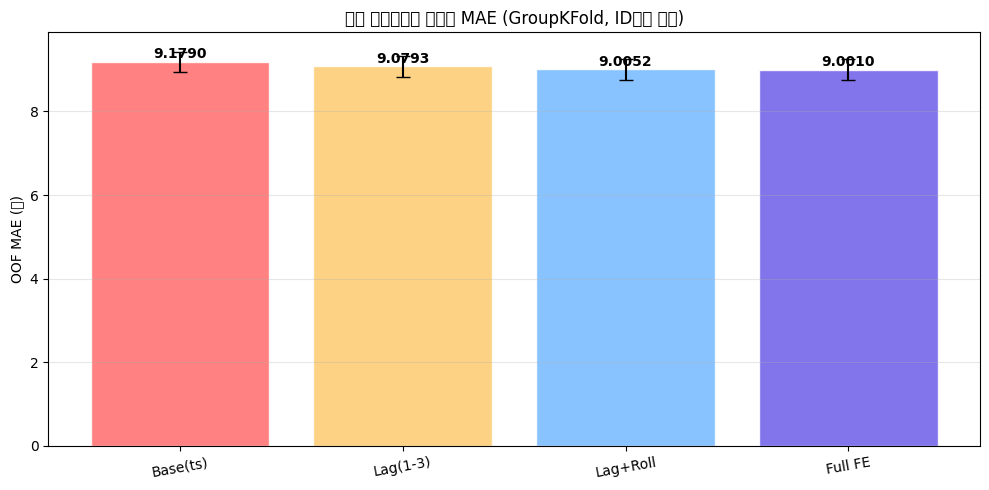

fe_progress.png 저장 완료


In [7]:
print('\n' + '='*60)
print('  피처 엔지니어링 단계별 결과')
print('='*60)
for name, res in RESULTS.items():
    print(f"  {name:20s}: MAE={res['mae']:.4f} (std={res['std']:.4f}) | feats={res['n_feats']}")
print('='*60)

fig, ax = plt.subplots(figsize=(10, 5))
names = list(RESULTS.keys())
maes  = [RESULTS[n]['mae'] for n in names]
stds  = [RESULTS[n]['std'] for n in names]
colors_ = ['#FF6B6B', '#FDCB6E', '#74B9FF', '#6C5CE7'][:len(names)]
bars = ax.bar(names, maes, color=colors_, alpha=0.85, edgecolor='white')
ax.errorbar(range(len(names)), maes, yerr=stds, fmt='none', color='black', capsize=5)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('OOF MAE (분)')
ax.set_title('피처 엔지니어링 단계별 MAE (GroupKFold, ID버그 수정)', fontsize=12)
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/fe_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print('fe_progress.png 저장 완료')


## 5. 피처 중요도

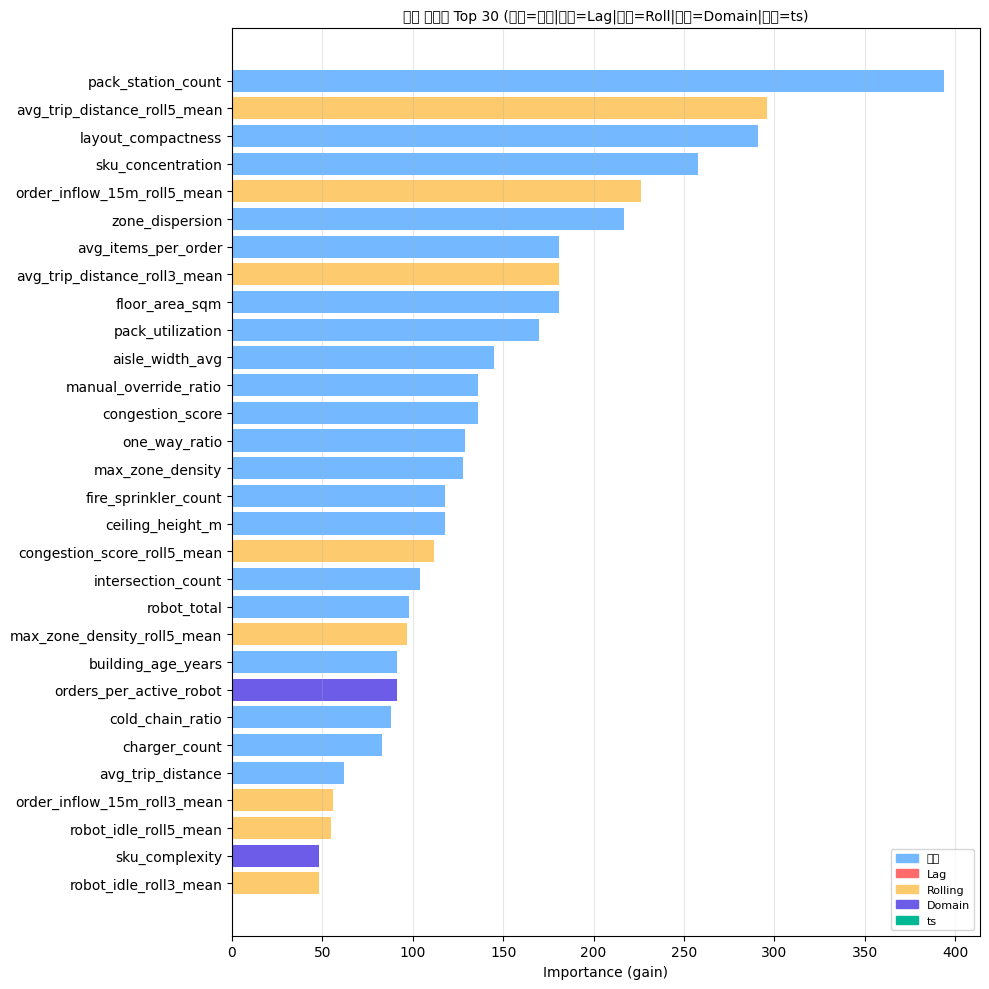


=== Top 10 피처 ===
  [orig  ] pack_station_count                 : 394.0
  [roll  ] avg_trip_distance_roll5_mean       : 296.0
  [orig  ] layout_compactness                 : 291.0
  [orig  ] sku_concentration                  : 258.0
  [roll  ] order_inflow_15m_roll5_mean        : 226.0
  [orig  ] zone_dispersion                    : 217.0
  [orig  ] avg_items_per_order                : 181.0
  [roll  ] avg_trip_distance_roll3_mean       : 181.0
  [orig  ] floor_area_sqm                     : 181.0
  [orig  ] pack_utilization                   : 170.0


In [8]:
feat_names = get_feature_cols(train_full, TARGET)
fi_df = pd.DataFrame({
    'feature': feat_names,
    'importance': fi_model.feature_importances_
}).sort_values('importance', ascending=False)

def get_color(name):
    if '_lag' in name: return '#FF6B6B'
    if '_roll' in name: return '#FDCB6E'
    if name in ['battery_crisis','robot_availability','charge_bottleneck',
                'battery_deficit','order_pressure','orders_per_active_robot',
                'congestion_x_order','sku_complexity']: return '#6C5CE7'
    if name.startswith('ts_'): return '#00B894'
    return '#74B9FF'

top30 = fi_df.head(30)
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(top30['feature'][::-1], top30['importance'][::-1],
        color=[get_color(f) for f in top30['feature'][::-1]])
ax.set_title('피처 중요도 Top 30 (파랑=원본|빨강=Lag|노랑=Roll|보라=Domain|초록=ts)', fontsize=10)
ax.set_xlabel('Importance (gain)')
ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for c, l in [
    ('#74B9FF','원본'), ('#FF6B6B','Lag'), ('#FDCB6E','Rolling'),
    ('#6C5CE7','Domain'), ('#00B894','ts')]], loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('../docs/full_fe_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 10 피처 ===')
for _, row in fi_df.head(10).iterrows():
    cat = 'lag' if '_lag' in row['feature'] else 'roll' if '_roll' in row['feature'] else 'domain' if row['feature'] in ['battery_crisis','robot_availability','charge_bottleneck','battery_deficit','order_pressure','orders_per_active_robot','congestion_x_order','sku_complexity'] else 'ts' if row['feature'].startswith('ts_') else 'orig'
    print(f"  [{cat:6s}] {row['feature']:35s}: {row['importance']:.1f}")


## 6. 제출 파일 생성 (ID 순서 검증 포함)

In [9]:
submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
best_label = min(RESULTS, key=lambda k: RESULTS[k]['mae'])
pred_map = {
    'Base(ts)': test_base_pred,
    'Lag(1-3)': test_lag_pred,
    'Lag+Roll': test_roll_pred,
    'Full FE' : test_full_pred,
}
best_preds = pred_map[best_label]

# 최종 ID 순서 검증
assert len(best_preds) == len(submission), f'길이 불일치: {len(best_preds)} vs {len(submission)}'
print(f'✅ 제출 파일 ID 수 일치: {len(submission)}')

submission['avg_delay_minutes_next_30m'] = best_preds.clip(min=0)
out_path = '../submissions/groupkfold_fullFE_lgbm_fixed.csv'
submission.to_csv(out_path, index=False)

print(f'\n최고 모델: {best_label} (MAE={RESULTS[best_label]["mae"]:.4f})')
print(f'제출 파일: {out_path}')
print(f'예측 통계: mean={best_preds.mean():.2f}, std={best_preds.std():.2f}, '
      f'min={best_preds.min():.2f}, max={best_preds.max():.2f}')
print(f'\n⚠️ 이전 groupkfold_fullFE_lgbm.csv는 ID 순서 버그로 잘못된 제출이었음')
print(f'✅ {out_path} 를 Dacon에 제출하세요')


✅ 제출 파일 ID 수 일치: 50000

최고 모델: Full FE (MAE=9.0010)
제출 파일: ../submissions/groupkfold_fullFE_lgbm_fixed.csv
예측 통계: mean=18.53, std=13.32, min=0.31, max=60.00

⚠️ 이전 groupkfold_fullFE_lgbm.csv는 ID 순서 버그로 잘못된 제출이었음
✅ ../submissions/groupkfold_fullFE_lgbm_fixed.csv 를 Dacon에 제출하세요
